## Analyzing Urban Networks: Calculating Basic Statistics with OSMnx

What We’ll Cover
- What network statistics are and why they’re useful.
- How to calculate basic statistics using OSMnx.
- How to interpret the results to gain insights into urban networks.

#### Case Study Location
For today’s case study, I chose Plaka, Athens, Greece. Plaka is a historic, pedestrian-friendly neighborhood at the foot of the Acropolis. Its narrow streets, neoclassical architecture, and archaeological sites make it a fascinating case study. Plus, analyzing pedestrian networks is fun!

#### Step 1: Downloading the Study Area
Let’s start by downloading the street network for Plaka. We’ll analyze an area within a 200-meter radius of a specific point.

In [2]:
import osmnx as ox
import folium
# Define the point and download the street network
place = (37.9725, 23.730278)
G = ox.graph_from_point(place, dist=200, network_type="walk")

#### Explanation
- graph_from_point(): This function downloads the street network within a specified distance (in meters) from a given point (latitude, longitude). In this case, we’re focusing on a 200-meter radius around a point in Plaka, Athens.
- network_type='walk': This parameter specifies that we’re interested in pedestrian paths. You can also use 'drive' for drivable roads or 'bike' for cycling routes, depending on your analysis goals.

#### Step 2: Visualizing the Area
Next, let’s visualize the street network with a basemap for context.

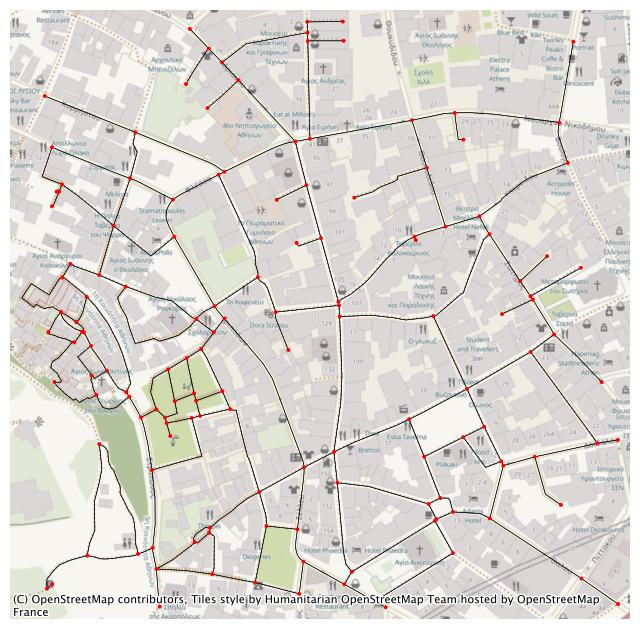

In [3]:
import contextily as cx
import matplotlib.pyplot as plt

# Plot the street network
fig, ax = ox.plot_graph(G, show=False, node_color="red", node_size=8, edge_linewidth=0.4, edge_color="black")
# Add a basemap
cx.add_basemap(ax, crs=G.graph["crs"])
# Show the plot
plt.show()

#### Explanation
- ox.plot_graph(): This function creates a visual representation of the street network. The nodes (intersections) are shown as red dots, and the edges (streets) are displayed as black lines.
- cx.add_basemap(): Adding a basemap provides geographical context, making it easier to interpret the street network in relation to real-world features like buildings, parks, and landmarks.

#### Step 3: Calculating Basic Statistics
Now, let’s calculate some basic statistics for the street network.

In [4]:
# Calculate basic statistics
stats = ox.basic_stats(G)
print(stats)

{'n': 142, 'm': 374, 'k_avg': 5.267605633802817, 'edge_length_total': 11487.282699127165, 'edge_length_avg': 30.714659623334665, 'streets_per_node_avg': 2.887323943661972, 'streets_per_node_counts': {0: 0, 1: 18, 2: 0, 3: 104, 4: 20}, 'streets_per_node_proportions': {0: 0.0, 1: 0.1267605633802817, 2: 0.0, 3: 0.7323943661971831, 4: 0.14084507042253522}, 'intersection_count': 124, 'street_length_total': 5743.641349563579, 'street_segment_count': 187, 'street_length_avg': 30.714659623334647, 'circuity_avg': 1.0421357861498861, 'self_loop_proportion': 0.0}


#### Explanation
- basic_stats() computes a variety of metrics, including the number of nodes, edges, and average street length.
The results are returned as a dictionary.

#### Step 4: Displaying the Statistics
To make the results more digestible, let’s display them in a table.

In [5]:
import pandas as pd

# Convert stats to a DataFrame for better readability
stats_df = pd.DataFrame.from_dict(stats, orient="index", columns=["Value"])
print(stats_df)

                                                                          Value
n                                                                           142
m                                                                           374
k_avg                                                                  5.267606
edge_length_total                                                  11487.282699
edge_length_avg                                                        30.71466
streets_per_node_avg                                                   2.887324
streets_per_node_counts                      {0: 0, 1: 18, 2: 0, 3: 104, 4: 20}
streets_per_node_proportions  {0: 0.0, 1: 0.1267605633802817, 2: 0.0, 3: 0.7...
intersection_count                                                          124
street_length_total                                                  5743.64135
street_segment_count                                                        187
street_length_avg                       


#### Step 5: Understanding The Statistics
Now we can interpret the results to understand the walkability, connectivity, and overall structure of the neighborhood. Here’s a detailed breakdown of what these metrics mean and how they can inform urban planning decisions:

#### Number of Nodes (n = 142):
- Interpretation: There are 142 intersections (nodes) in the analyzed area.
- Implications: This indicates a relatively dense network of intersections, which is typical for historic, pedestrian-friendly neighborhoods. It suggests good connectivity and multiple route options for pedestrians.

#### Number of Edges (m = 370):
- Interpretation: There are 370 street segments (edges) connecting the nodes.
- Implications: A high number of edges relative to nodes indicates a well-connected street network, which is ideal for walkability. Pedestrians have many paths to choose from, reducing congestion on any single route.


#### Average Node Degree (k_avg = 5.21):
- Interpretation: On average, each intersection connects to about 5.21 street segments.
- Implications: A high average degree suggests a highly interconnected network. This is excellent for pedestrian mobility, as it provides multiple route choices and reduces travel distances.

#### Total Edge Length (edge_length_total = 11,475.11 meters):
- Interpretation: The total length of all street segments in the network is approximately 11.5 kilometers.
- Implications: This metric gives a sense of the scale of the area. For a small, historic neighborhood like Plaka, this is a reasonable total length, indicating a compact and walkable area.

#### Average Edge Length (edge_length_avg = 31.01 meters):
- Interpretation: The average street segment is about 31 meters long.
- Implications: Short street segments are typical in historic, pedestrian-friendly areas. They contribute to a fine-grained urban fabric, making the area more walkable and visually interesting.

#### Average Streets per Node (streets_per_node_avg = 2.86):
- Interpretation: On average, each intersection has about 2.86 streets meeting at it.
- Implications: This indicates a mix of intersections with varying degrees of connectivity. It’s common in historic areas where streets don’t follow a strict grid pattern.

#### Streets per Node Counts:
Interpretation:

- 20 intersections have 1 street (dead ends).
- 102 intersections have 3 streets.
- 20 intersections have 4 streets.
Implications: The high number of 3-way and 4-way intersections suggests a well-connected network. Dead ends (1-street nodes) are minimal, which is good for walkability.

#### Intersection Count (intersection_count = 122):
- Interpretation: There are 122 intersections in the network.
- Implications: This confirms the area’s high connectivity, which is beneficial for pedestrian movement and wayfinding.

#### Total Street Length (street_length_total = 5,737.55 meters):
- Interpretation: The total length of unique streets (excluding overlaps) is about 5.7 kilometers.
- Implications: This metric helps quantify the overall walkable area. For a small neighborhood like Plaka, this is a reasonable length, indicating a compact and walkable environment.

#### Street Segment Count (street_segment_count = 185):
- Interpretation: There are 185 unique street segments.
- Implications: This reinforces the area’s fine-grained urban fabric, which is typical of historic, pedestrian-friendly neighborhoods.

#### Average Street Length (street_length_avg = 31.01 meters):
- Interpretation: The average length of unique streets is about 31 meters.
- Implications: Short street lengths are ideal for walkability, as they create a human-scale environment and encourage exploration.

#### Average Circuity (circuity_avg = 1.04):
- Interpretation: The average circuity (ratio of network path length to straight-line distance) is 1.04.
- Implications: A circuity close to 1 indicates that the street network is relatively direct, which is good for pedestrian efficiency. However, the slight deviation from 1 adds character and reflects the organic layout of historic neighborhoods.

#### Self-Loop Proportion (self_loop_proportion = 0.0):
- Interpretation: There are no self-loops (edges that start and end at the same node).
- Implications: This is typical for street networks and doesn’t significantly impact walkability.

#### Urban Planning Insights
- Walkability: The high density of nodes and edges, combined with short street lengths, makes Plaka highly walkable. Pedestrians can easily navigate the area, and the fine-grained street network encourages exploration.
- Connectivity: The high average node degree (5.21) and the prevalence of 3-way and 4-way intersections indicate excellent connectivity. This reduces the likelihood of congestion on any single route and provides multiple path options.
- Historic Character: The organic layout, with its mix of short streets and irregular intersections, reflects the historic character of Plaka. While this adds charm, it may also pose challenges for accessibility (e.g., for people with mobility issues).

#### Potential Improvements:
- Accessibility: Some dead ends (1-street nodes) could be addressed to improve connectivity further.
- Pedestrian Infrastructure: Adding benches, signage, and pedestrian-friendly crossings could enhance the walking experience.
- Traffic Calming: While Plaka is primarily pedestrian-friendly, any vehicular traffic should be carefully managed to maintain the area’s walkability.

#### Tourism and Economic Activity
The dense, interconnected network supports tourism by making it easy for visitors to explore the area on foot. This can boost local businesses and cultural engagement.

#### Step 6: Try It Yourself!
Replace "Plaka, Athens, Greece" with your city or neighborhood and calculate the statistics. Experiment with different network_type values ('drive', 'walk', 'bike') to see how the metrics change.

